# Indicador ODS-14.1.1a - Eutrofização Costeiro-Marinha do Brasil


## Ciclo de Vida dos Dados com CRISP-DM

Neste exercício vamos aplicar as etapas do **CRISP-DM** a criação deste indicador.

Objetivo geral:

> Usar como dados de entrada imagens do sensor SGLI (Second-Generation Global Imager) do satélite GCOM-C (Shikisai) da faz parte da missão GCOM (Global Change Observation Mission) desenvolvida pela JAXA (Agência de Exploração Aeroespacial do Japão)

As etapas segundo padrão CRISP-DM serão:

1. Compreensão do Negócio
2. Compreensão dos Dados
3. Preparação dos Dados
4. Modelagem
5. Avaliação
6. Implantação


# 1. Compreensão do Negócio

O IBGE precisa nacionalizar os indicadores ODS. Dentre os indicadores temos o ODS-14.1.1a. Este indicador é Índice de Eutrofização Costeira (Index of Coastal Eutrophication — ICEP). Ele é um subindicador oficial da Meta 14.1 dos Objetivos de Desenvolvimento Sustentável da ONU (ODS 14: Vida na Água).


## Pergunta do projeto

É possível calcular com sensoriamento remoto o indicador 14.1.1a com sensoriamento remoto internacional correspondentes a aferições locais ?

## Objetivo

1. Obter o dataset de Clorofila-a do site FTP da Agência Espacial Japonesa JAXA
2. Obter os polígonos vetoriais da Cadastro Naacional das Unidades de Conservação - CNUC - do site do MMA.
3. Transformar dados matatriciais em imagens GeoTiff;
4. Corrigir a projeção das imagens para mesma projeção das feições dos polígonos do CNUC;
5. Fazer o recorte das imagens para a área delimitada das Unidades de Conservação Costeiro-Marinhas;
4. construir um `DataFrame` multimodal;
5. O canal de cor da imagem em escala logarítmica;
6. Ajustar o modelo linear da imagem $f(y) = Pixel(w) + b $ , onde $f(x)$ é a massa seca de plancton, $Pixel$ é o valor da imagem, e $w$ (peso) e $b$ (vício) são valores de calibração do sensor.
7. Gerar, para cada imagem localizada no tempo e espaço (UC), um label (valor de placton dissolvido) em $\frac{mg}{m^3}$
8. Gerar a série rotulada.
6. separar dados de treino e teste;
7. treinar um modelo de regressão linear, devido a natureza do fenômeno;
8. Checar se modelo suporta sazonalidade, acrescentar mais variáveis de entrada;
8. avaliar o modelo (Teste) e calcular o erro. dados In situ vs dados Previstos;
9. usar o modelo para classificar uma nova observação.


# 2. Compreensão dos Dados

A entrada $x_1$ são as imagens da agencia japonesa. O moisaico será o CRHA global.

- Formato - (Matricial - NetCDF);
- Canais de Dados - 1 canal de cor de 16 bits;
- Resolução Temporal: 2018 a 2026
- Resolução Espacial: Global - Projeção eixo "x" de 0 a 360 - Necessita conversão.
- Variáveis de sensor: Estão embarcadas na matriz da imagem.

A entrada $x_2$ são feições vetoriais poliginares do Banco de dados CNUC (Cadastro Nacional de Unidades de Conservação) do M.M.A.

- Formato - SHP;
- Canais de Dados - 1 vetorial (geom) + atributos (características) tabulares de cada feição;
- Resolução Temporal: 1984 a 2026
- Resolução Espacial: EPSG:4674 - Sirgas 2000 geográfico
- variáveis anexas: (Conferir metados no site do CNUC).
- Usa geocódigo do IBGE ? SIM



## 2.1 Importar bibliotecas


Instalar o pacote tqdm para baixar as imagens da agência espacial Japonesa.

In [1]:
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable


## 2.2 Executar o programa para obter as imagens matriciais multi-dimensionais netcdf

In [ ]:
import os
import ftplib
from tqdm.notebook import tqdm

# Configurações do servidor FTP
FTP_HOST = "apollo.eorc.jaxa.jp"
FTP_USER = "anonymous"
FTP_PASS = "miguel.penteado@ibge.gov.br"  # Senha em branco para login anônimo

# Diretório remoto inicial no FTP e diretório local onde os arquivos serão salvos
REMOTE_BASE_DIR = "/pub/SGLI_STD/Global_05km/8-day/CHLA"  # <-- Altere para o caminho remoto desejado
LOCAL_BASE_DIR = "./downloads_jaxa"       # Pasta local de destino

def download_file(ftp, remote_filepath, local_filepath):
    """Baixa um único arquivo do FTP mostrando barra de progresso."""
    # Garante que o diretório local existe
    os.makedirs(os.path.dirname(local_filepath), exist_ok=True)

    # Obter tamanho do arquivo remoto para a barra de progresso
    try:
        total_size = ftp.size(remote_filepath)
    except Exception:
        total_size = None  # Alguns servidores FTP não suportam o comando SIZE

    # Prepara a barra de progresso do tqdm
    filename = os.path.basename(remote_filepath)
    progress_bar = tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc=filename,
        leave=False
    )

    def callback(data):
        progress_bar.update(len(data))
        with open(local_filepath, "ab") as f:
            f.write(data)

    # Remove o arquivo local se ele ficou incompleto em uma execução anterior
    if os.path.exists(local_filepath):
        os.remove(local_filepath)

    # Executa o download
    ftp.retrbinary(f"RETR {remote_filepath}", callback)
    progress_bar.close()

def download_recursive(ftp, remote_dir, local_dir):
    """Navega recursivamente pelas subpastas e baixa arquivos .nc."""
    try:
        items = ftp.nlst(remote_dir)
    except ftplib.error_perm as e:
        # Diretório vazio ou sem permissão de leitura
        return

    for item in items:
        # Evita loops com referências de diretório atual e pai
        if item.endswith("/.") or item.endswith("/.."):
            continue

        item_name = os.path.basename(item)
        local_path = os.path.join(local_dir, item_name)

        # Tenta mudar para o item para checar se é um diretório
        try:
            ftp.cwd(item)
            # Se funcionou, é um diretório: cria pasta local e entra na recursão
            os.makedirs(local_path, exist_ok=True)
            download_recursive(ftp, item, local_path)
            ftp.cwd("..")  # Retorna ao diretório anterior
        except ftplib.error_perm:
            # Se falhou o cwd, trata-se de um arquivo
            if item.lower().endswith(".nc"):
                print(f"Baixando: {item}")
                download_file(ftp, item, local_path)

def main():
    print(f"Conectando ao servidor FTP {FTP_HOST}...")
    ftp = ftplib.FTP(FTP_HOST)
    ftp.login(user=FTP_USER, passwd=FTP_PASS)
    print("Conexão estabelecida com sucesso!")

    try:
        download_recursive(ftp, REMOTE_BASE_DIR, LOCAL_BASE_DIR)
        print("\nDownload concluído com sucesso!")
    finally:
        ftp.quit()

# Executar o download
main()

Baixando: /pub/SGLI_STD/Global_05km/8-day/CHLA/2026/GC1SG1_20260202A08D_D0000_3MSG_CHLAM_3000.nc


GC1SG1_20260202A08D_D0000_3MSG_CHLAM_3000.nc:   0%|          | 0.00/241k [00:00<?, ?B/s]

Baixando: /pub/SGLI_STD/Global_05km/8-day/CHLA/2026/GC1SG1_20260218A08D_D0000_3MSG_CHLAM_3000.nc


GC1SG1_20260218A08D_D0000_3MSG_CHLAM_3000.nc:   0%|          | 0.00/241k [00:00<?, ?B/s]

Baixando: /pub/SGLI_STD/Global_05km/8-day/CHLA/2026/GC1SG1_20260712D08D_D0000_3MSG_CHLAM_3000.nc


...

GC1SG1_20180610D08D_D0000_3MSG_CHLAM_3000.nc:   0%|          | 0.00/21.6M [00:00<?, ?B/s]

Baixando: /pub/SGLI_STD/Global_05km/8-day/CHLA/2018/GC1SG1_20180117A08D_D0000_3MSG_CHLAM_3000.nc


GC1SG1_20180117A08D_D0000_3MSG_CHLAM_3000.nc:   0%|          | 0.00/225k [00:00<?, ?B/s]

Baixando: /pub/SGLI_STD/Global_05km/8-day/CHLA/2018/GC1SG1_20180906D08D_D0000_3MSG_CHLAM_3000.nc


GC1SG1_20180906D08D_D0000_3MSG_CHLAM_3000.nc:   0%|          | 0.00/27.5M [00:00<?, ?B/s]

## 2.3 Converter as imagens NetCDF para GeoTiff e projeção latitude de 0 - 360 para -180 a +180

In [ ]:
import os
import glob
from osgeo import gdal

# Define o diretório raiz.
# '.' significa o diretório atual onde o script está sendo executado.
diretorio = '.'

# Busca todos os arquivos .nc no diretório atual
# e em todos os seus subdiretórios.
arquivos_nc = glob.glob(
    os.path.join(diretorio, '**', '*.nc'),
    recursive=True
)

if not arquivos_nc:
    print("Nenhum arquivo .nc encontrado no diretório ou subdiretórios.")
else:
    print(f"Encontrados {len(arquivos_nc)} arquivos para conversão.\n")

for arquivo in arquivos_nc:

    print("=" * 80)
    print(f"Processando: {arquivo}")

    # 1. Abre o arquivo NetCDF para ler as Subdatasets
    dataset = gdal.Open(arquivo)

    if dataset is None:
        print(f"Erro ao abrir o arquivo: {arquivo}")
        continue

    subdatasets = dataset.GetSubDatasets()

    if not subdatasets:
        print(f"Nenhuma subdataset encontrada em: {arquivo}")
        dataset = None
        continue

    # A primeira subdataset
    # Exemplo:
    # NETCDF:"nome_do_arquivo.nc":CHLA_AVE
    subdataset_1_name = subdatasets[0][0]

    print(f"Subdataset selecionada: {subdataset_1_name}")

    # Fecha o dataset principal, pois já obtivemos
    # a identificação da subdataset.
    dataset = None

    # 2. Define o arquivo GeoTIFF de saída.
    # O GeoTIFF será criado no mesmo diretório do NetCDF.
    arquivo_saida = os.path.splitext(arquivo)[0] + '.tif'

    # 3. Monta o comando gdalwarp
    comando = (
        f'gdalwarp -of GTiff '
        f'-s_srs "+proj=longlat +ellps=WGS84 +lon_warp=180" '
        f'-t_srs EPSG:4326 '
        f'-te -180 -90 180 90 '
        f'-ts 7200 3601 '
        f'"{subdataset_1_name}" '
        f'"{arquivo_saida}"'
    )

    # 4. Executa o comando
    print(f"Executando conversão...")
    print(f"Entrada : {arquivo}")
    print(f"Saída   : {arquivo_saida}")

    status = os.system(comando)

    if status == 0:
        print(f"Sucesso: {arquivo_saida}\n")
    else:
        print(f"Erro ao processar: {arquivo}\n")

print("=" * 80)
print("Processo concluído!")

## 2.4 Obter os polígonos do CNUC (Cadastro Nacional de Unidades de Conservação) do Ministério do Meio Ambiente

Você deve fazer download do arquivo (arquivo compactado) **ucs.zip** no site https://cnuc.mma.gov.br/map

In [6]:
import requests

url = "https://cnuc-backend.mma.gov.br/api/v1/downloadGeo"

headers = {
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "pt-BR,pt;q=0.7",
    "Connection": "keep-alive",
    "Content-Type": "application/json;charset=UTF-8",
    "Email": "null",
    "IdUser": "null",
    "Origin": "https://cnuc.mma.gov.br",
    "Referer": "https://cnuc.mma.gov.br/",
    "Sec-Fetch-Dest": "empty",
    "Sec-Fetch-Mode": "cors",
    "Sec-Fetch-Site": "same-site",
    "Sec-GPC": "1",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/154.0.0.0 Safari/537.36",
    "panel": "null",
    "sec-ch-ua": '"Chromium";v="154", "Brave";v="154", "Not A(Brand";v="99"',
    "sec-ch-ua-mobile": "?0",
    "sec-ch-ua-platform": '"Windows"',
    "sphere": "null",
    "uf": "null",
}

payload = {
    "format": "shp",
    "map": "/var/www/storage/app/mapfiles/ucs.map",
    "name": "ucs",
    "typename": "ucs_selected",
    "ucIds": "null"
}

# Realiza a requisição POST enviando o JSON
response = requests.post(url, headers=headers, json=payload)

# Salva o resultado no arquivo arquivo teste.zip
if response.status_code == 200:
    with open("cnuc_unidades_de_conservacao.zip", "wb") as f:
        f.write(response.content)
    print("Download concluído com sucesso!")
else:
    print(f"Erro na requisição: {response.status_code}")
    print(response.text)

Download concluído com sucesso!


### 2.4.1 Descompacte o arquivo zipado
Extraia o conteúdo do arquivo zipado **cnuc_unidades_de_conservacao.zip** para a pasta  ""camada_vetorial_cnuc""

In [ ]:
import os
import zipfile

# Nome do arquivo ZIP e da pasta de destino
zip_filename = "cnuc_unidades_de_conservacao.zip"
output_folder = "camada_vetorial_cnuc"

# Cria a pasta caso ela não exista
os.makedirs(output_folder, exist_ok=True)

# Extrai o conteúdo do arquivo ZIP
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(output_folder)

print(f"Conteúdo extraído com sucesso para a pasta '{output_folder}'.")

## Visualize as unidades de conservação em um cartograma

Use
- a imagem Raster "GC1SG1_20260101A08D_D0000_3MSG_CHLAM_3000.tif" como camada base e
- a camada vetorial "ucs.shp" como primeira camada

CRS do Raster (JAXA): EPSG:4326
CRS original do Vetor: EPSG:4674
Reprojetando vetor de EPSG:4674 para EPSG:4326...


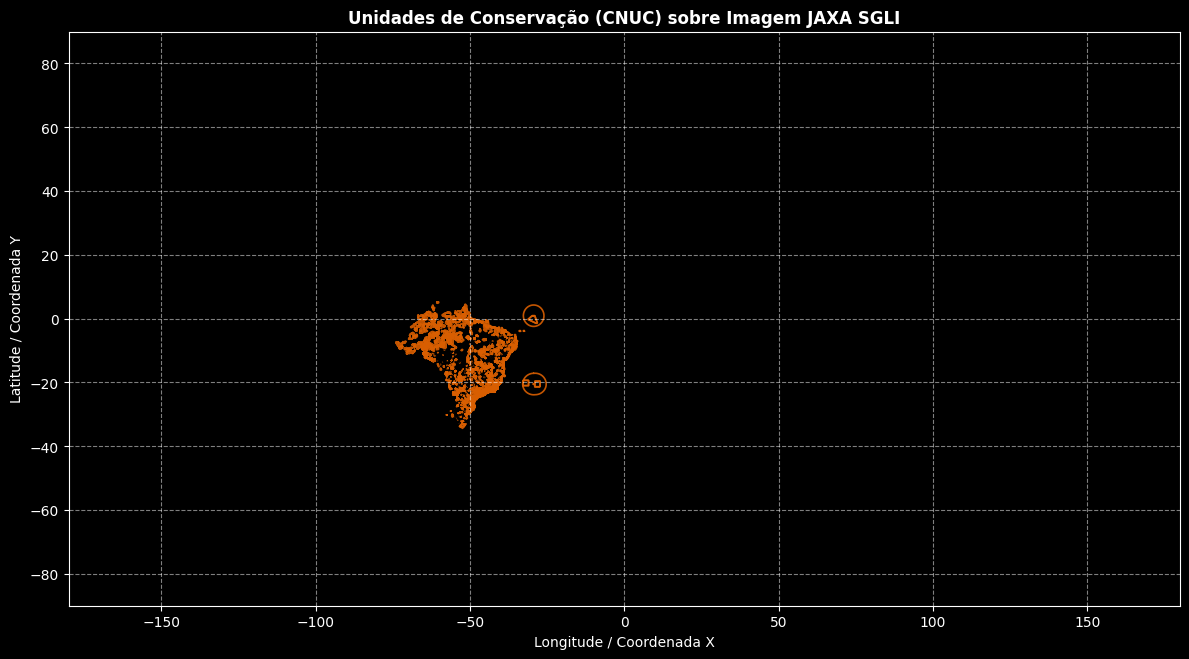

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

# Caminhos dos arquivos
raster_path = r"downloads_jaxa\2026\GC1SG1_20260101A08D_D0000_3MSG_CHLAM_3000.tif"
vector_path = r"camada_vetorial_cnuc\ucs.shp"

# 1. Carrega o vetor das Unidades de Conservação
gdf_ucs = gpd.read_file(vector_path)

# Se o arquivo .prj não tiver sido identificado automaticamente, define o CRS como EPSG:4674
if gdf_ucs.crs is None:
    gdf_ucs.set_crs(epsg=4674, inplace=True)

# 2. Configura a figura do matplotlib
fig, ax = plt.subplots(figsize=(12, 10))

# 3. Abre o raster do JAXA, reprojeta o vetor se necessário e exibe ambas as camadas
with rasterio.open(raster_path) as src:
    print(f"CRS do Raster (JAXA): {src.crs}")
    print(f"CRS original do Vetor: {gdf_ucs.crs}")

    # Reprojeta o vetor (EPSG:4674) para o mesmo CRS do raster (ex: EPSG:4326 ou outro)
    if gdf_ucs.crs != src.crs:
        print(f"Reprojetando vetor de {gdf_ucs.crs} para {src.crs}...")
        gdf_ucs = gdf_ucs.to_crs(src.crs)

    # Plota a imagem raster como fundo
    show(src, ax=ax, title="Unidades de Conservação (CNUC) sobre Imagem JAXA SGLI")

# 4. Plota o vetor reprojetado por cima
gdf_ucs.plot(
    ax=ax,
    facecolor='none',       # Sem preenchimento para enxergar o raster abaixo
    edgecolor='#d95f02',    # Cor de destaque (laranja/vermelho)
    linewidth=1.2,
    alpha=0.9,
    label='Unidades de Conservação (SIRGAS 2000)'
)

# 5. Ajustes estéticos
ax.set_xlabel("Longitude / Coordenada X")
ax.set_ylabel("Latitude / Coordenada Y")
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Atividade 1

Investigue o JSON retornado pela API e identifique:

1. o nome da variável;
2. a unidade de medida;
3. onde está o nome do município;
4. onde está o código do município;
5. onde está o período;
6. onde está armazenado o valor da população urbana.


# 3. Preparação dos Dados

Agora vamos transformar o JSON em uma estrutura tabular.

Cada município será uma **observação**.

A variável que utilizaremos será:

`populacao_urbana`


## 3.1 Extrair os municípios e suas populações


In [11]:
resultados = []

for resultado in dados[0]["resultados"]:
    for serie in resultado["series"]:

        localidade = serie["localidade"]
        valores = serie["serie"]

        valor_2022 = valores.get("2022")

        if valor_2022 not in (None, "-", "...", "X"):
            resultados.append({
                "codigo": int(localidade["id"]),
                "municipio": localidade["nome"],
                "ano": 2022,
                "populacao_urbana": int(valor_2022)
            })

len(resultados)


645

### Atividade 2

- Explique o que o código anterior fez.

- Observe especialmente esta sequência:

`dados → resultados → series → localidade → serie`

Por que foi necessário percorrer vários níveis do JSON?


## 3.2 Construir o DataFrame


In [12]:
df_sp = pd.DataFrame(resultados)

df_sp.head()


,codigo,municipio,ano,populacao_urbana
0,3500105,Adamantina - SP,2022,33536
1,3500204,Adolfo - SP,2022,4005
2,3500303,Aguaí - SP,2022,29895
3,3500402,Águas da Prata - SP,2022,6459
4,3500501,Águas de Lindóia - SP,2022,15627


In [13]:
print("Quantidade de municípios recuperados:", len(df_sp))


Quantidade de municípios recuperados: 645


## 3.3 Selecionar 100 municípios

Vamos escolher **100 municípios aleatoriamente**, usando `random_state=42`.

O valor fixo de `random_state` garante que todos os alunos obtenham a mesma amostra.


In [14]:
df = (
    df_sp
    .sample(n=100, random_state=42)
    .sort_values("populacao_urbana")
    .reset_index(drop=True)
)

df


,codigo,municipio,ano,populacao_urbana
0,3507209,Borá - SP,2022,738
1,3515806,Flora Rica - SP,2022,1216
2,3555307,Turmalina - SP,2022,1261
3,3532843,Nova Canaã Paulista - SP,2022,1352
4,3554755,Trabiju - SP,2022,1554
...,...,...,...,...
95,3515004,Embu das Artes - SP,2022,249223
96,3518701,Guarujá - SP,2022,286839
97,3551009,São Vicente - SP,2022,329607
98,3549904,São José dos Campos - SP,2022,688155


## 3.4 Verificar tipos e dados ausentes


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   codigo            100 non-null    int64 
 1   municipio         100 non-null    object
 2   ano               100 non-null    int64 
 3   populacao_urbana  100 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 3.3+ KB


In [16]:
df.isnull().sum()


,0
codigo,0
municipio,0
ano,0
populacao_urbana,0


## 3.5 Estatística descritiva


In [17]:
df["populacao_urbana"].describe().round(2)


,populacao_urbana
count,100.00
mean,"55,859.13"
std,"141,198.55"
min,738.00
25%,"5,723.25"
50%,"13,058.50"
75%,"42,254.25"
max,"1,132,934.00"


## 3.6 Criar classes de porte populacional

Como esta é uma atividade didática, vamos dividir os 100 municípios em três grupos de tamanhos aproximadamente semelhantes usando os tercis da própria amostra.

Assim teremos classes mais equilibradas para o treinamento do KNN.

> Essas classes são criadas apenas para fins didáticos e não representam uma classificação oficial do IBGE.


In [18]:
df["porte"] = pd.qcut(
    df["populacao_urbana"],
    q=3,
    labels=["Pequena", "Média", "Grande"]
)

df


,codigo,municipio,ano,populacao_urbana,porte
0,3507209,Borá - SP,2022,738,Pequena
1,3515806,Flora Rica - SP,2022,1216,Pequena
2,3555307,Turmalina - SP,2022,1261,Pequena
3,3532843,Nova Canaã Paulista - SP,2022,1352,Pequena
4,3554755,Trabiju - SP,2022,1554,Pequena
...,...,...,...,...,...
95,3515004,Embu das Artes - SP,2022,249223,Grande
96,3518701,Guarujá - SP,2022,286839,Grande
97,3551009,São Vicente - SP,2022,329607,Grande
98,3549904,São José dos Campos - SP,2022,688155,Grande


### Atividade 3 — Quantos municípios existem em cada classe?


In [19]:
df["porte"].value_counts().sort_index()


,count
porte,
Pequena,34
Média,32
Grande,34


# 4. Modelagem

Utilizaremos o algoritmo **K-Nearest Neighbors — KNN**.

Neste exercício:

- Entrada `X` = população urbana;
- Saída   `y` = porte populacional do município.

Caso seja inserida uma nova cidade no dataset, um modelo tipo KNN verificará quais observações conhecidas estão mais próximas de uma nova cidade.

> Neste exemplo há apenas uma variável de entrada. O objetivo principal é **praticar o ciclo CRISP-DM** e o verificar o funcionamento de treino/teste com KNN.


## 4.1 Definir X e y


In [20]:
X = df[["populacao_urbana"]]
y = df["porte"]


In [21]:
X.head()


,populacao_urbana
0,738
1,1216
2,1261
3,1352
4,1554


In [22]:
y.head()


,porte
0,Pequena
1,Pequena
2,Pequena
3,Pequena
4,Pequena


## 4.2 Separar treino e teste

Vamos utilizar:

- 70% dos municípios para treino;
- 30% para teste.

O argumento `stratify=y` preserva aproximadamente a proporção das três classes nos dois conjuntos.


In [23]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Treino:", len(X_treino))
print("Teste :", len(X_teste))


Treino: 70
Teste : 30


## 4.3 Criar o modelo KNN


In [24]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=3)


## 4.4 Treinar o modelo


In [25]:
modelo.fit(X_treino, y_treino)


KNeighborsClassifier(n_neighbors=3)

O método `fit()` utiliza os dados de treino.

No KNN, o treinamento consiste principalmente em armazenar as observações de treino para posteriormente comparar novas observações com seus vizinhos.


# 5. Avaliação

Agora vamos utilizar os 30 municípios reservados para teste.

Esses municípios não foram utilizados pelo modelo durante o treinamento.


In [26]:
y_pred = modelo.predict(X_teste)

y_pred


array(['Média', 'Média', 'Média', 'Média', 'Grande', 'Pequena', 'Grande',
       'Grande', 'Média', 'Pequena', 'Grande', 'Média', 'Pequena',
       'Grande', 'Pequena', 'Pequena', 'Grande', 'Grande', 'Pequena',
       'Pequena', 'Grande', 'Grande', 'Média', 'Média', 'Pequena',
       'Média', 'Grande', 'Pequena', 'Pequena', 'Média'], dtype=object)

## 5.1 Comparar valores reais e previstos


In [27]:
resultado = pd.DataFrame({
    "populacao_urbana": X_teste["populacao_urbana"],
    "Real": y_teste,
    "Previsto": y_pred
}).sort_values("populacao_urbana")

resultado


,populacao_urbana,Real,Previsto
1,1216,Pequena,Pequena
3,1352,Pequena,Pequena
5,1712,Pequena,Pequena
7,2225,Pequena,Pequena
9,2407,Pequena,Pequena
13,2646,Pequena,Pequena
16,2929,Pequena,Pequena
17,2963,Pequena,Pequena
21,4139,Pequena,Pequena
31,6736,Pequena,Pequena


## 5.2 Calcular a acurácia


In [28]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_teste, y_pred)

print(f"Acurácia: {acuracia:.2%}")


Acurácia: 100.00%


## 5.3 Matriz de confusão


In [29]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(
    y_teste,
    y_pred,
    labels=["Pequena", "Média", "Grande"]
)

pd.DataFrame(
    matriz,
    index=["Real Pequena", "Real Média", "Real Grande"],
    columns=["Prev. Pequena", "Prev. Média", "Prev. Grande"]
)


,Prev. Pequena,Prev. Média,Prev. Grande
Real Pequena,10,0,0
Real Média,0,10,0
Real Grande,0,0,10


### Atividade 4

Responda:

1. Quantos municípios foram utilizados para treinamento?
2. Quantos foram utilizados para teste?
3. Quantos municípios foram classificados corretamente?
4. Qual foi a acurácia?
5. Em qual classe ocorreram mais erros?
6. Por que usar 100 observações é mais adequado que utilizar apenas 10?
7. O que aconteceria se alterássemos `K=3` para `K=5` ou `K=7`?


# 6. Implantação

Vamos simular uma pequena função que recebe a população urbana de uma nova cidade e devolve a classe prevista pelo modelo.


In [30]:
def prever_porte(populacao_urbana):
    nova_cidade = pd.DataFrame({
        "populacao_urbana": [populacao_urbana]
    })

    return modelo.predict(nova_cidade)[0]


In [31]:
prever_porte(250000)


'Grande'

## 6.1 Teste com diferentes populações

Experimente diferentes valores e observe a classificação retornada pelo modelo.


In [32]:
for populacao in [20000, 100000, 250000, 600000, 1000000]:
    print(
        f"{populacao:>10,} habitantes -> "
        f"{prever_porte(populacao)}"
    )


    20,000 habitantes -> Média
   100,000 habitantes -> Grande
   250,000 habitantes -> Grande
   600,000 habitantes -> Grande
 1,000,000 habitantes -> Grande


# 7. Fechamento — CRISP-DM

Neste notebook percorremos o ciclo completo:

### 1. Compreensão do Negócio
Definimos o problema de classificação dos municípios.

### 2. Compreensão dos Dados
Investigamos a API REST do IBGE e a estrutura JSON.

### 3. Preparação dos Dados
Transformamos o JSON em `DataFrame`, selecionamos 100 municípios e criamos as classes.

### 4. Modelagem
Criamos e treinamos um modelo KNN.

### 5. Avaliação
Utilizamos dados de teste, calculamos acurácia e matriz de confusão.

### 6. Implantação
Criamos uma função para classificar uma nova observação.

O ciclo pode ser repetido posteriormente utilizando outras variáveis, outros estados, novos critérios de classificação ou outros algoritmos.
